In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_csv("customer_transactions_final.csv")

In [4]:
df.head()

,customer_id,age,age_group,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases_days
0,1,55,middle_aged,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,14
1,2,19,young_adult,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,14
2,3,50,middle_aged,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,7
3,4,21,young_adult,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,7
4,5,45,middle_aged,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,365


In [6]:
df.tail()

,customer_id,age,age_group,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases_days
3895,3896,40,adult,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,32,Venmo,7
3896,3897,52,middle_aged,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,41,Bank Transfer,14
3897,3898,46,middle_aged,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,24,Venmo,90
3898,3899,44,middle_aged,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,24,Venmo,7
3899,3900,52,middle_aged,Female,Handbag,Accessories,81,California,M,Beige,Spring,3.1,No,Store Pickup,No,33,Venmo,90


In [7]:
df.describe()

,customer_id,age,purchase_amount,review_rating,previous_purchases,frequency_of_purchases_days
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750051,25.351538,89.133077
std,1125.977353,15.207589,23.685392,0.713590,14.447125,119.037566
min,1.000000,18.000000,20.000000,2.500000,1.000000,7.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000,14.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000,30.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000,90.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000,365.000000


In [8]:
df.shape

(3900, 18)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_id                  3900 non-null   int64  
 1   age                          3900 non-null   int64  
 2   age_group                    3900 non-null   object 
 3   gender                       3900 non-null   object 
 4   item_purchased               3900 non-null   object 
 5   category                     3900 non-null   object 
 6   purchase_amount              3900 non-null   int64  
 7   location                     3900 non-null   object 
 8   size                         3900 non-null   object 
 9   color                        3900 non-null   object 
 10  season                       3900 non-null   object 
 11  review_rating                3900 non-null   float64
 12  subscription_status          3900 non-null   object 
 13  shipping_type     

In [13]:
df.isnull().sum()

customer_id                    0
age                            0
age_group                      0
gender                         0
item_purchased                 0
category                       0
purchase_amount                0
location                       0
size                           0
color                          0
season                         0
review_rating                  0
subscription_status            0
shipping_type                  0
discount_applied               0
previous_purchases             0
payment_method                 0
frequency_of_purchases_days    0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.nunique()

customer_id                    3900
age                              53
age_group                         4
gender                            2
item_purchased                   25
category                          4
purchase_amount                  81
location                         50
size                              4
color                            25
season                            4
review_rating                    26
subscription_status               2
shipping_type                     6
discount_applied                  2
previous_purchases               50
payment_method                    6
frequency_of_purchases_days       5
dtype: int64

In [16]:
df.columns

Index(['customer_id', 'age', 'age_group', 'gender', 'item_purchased',
       'category', 'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases_days'],
      dtype='object')

In [13]:
features = [
    'age',
    'purchase_amount',
    'previous_purchases',
    'frequency_of_purchases_days',
    'review_rating'
]

df[features].describe()

,age,purchase_amount,previous_purchases,frequency_of_purchases_days,review_rating
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,25.351538,89.133077,3.750051
std,15.207589,23.685392,14.447125,119.037566,0.713590
min,18.000000,20.000000,1.000000,7.000000,2.500000
25%,31.000000,39.000000,13.000000,14.000000,3.100000
50%,44.000000,60.000000,25.000000,30.000000,3.800000
75%,57.000000,81.000000,38.000000,90.000000,4.400000
max,70.000000,100.000000,50.000000,365.000000,5.000000


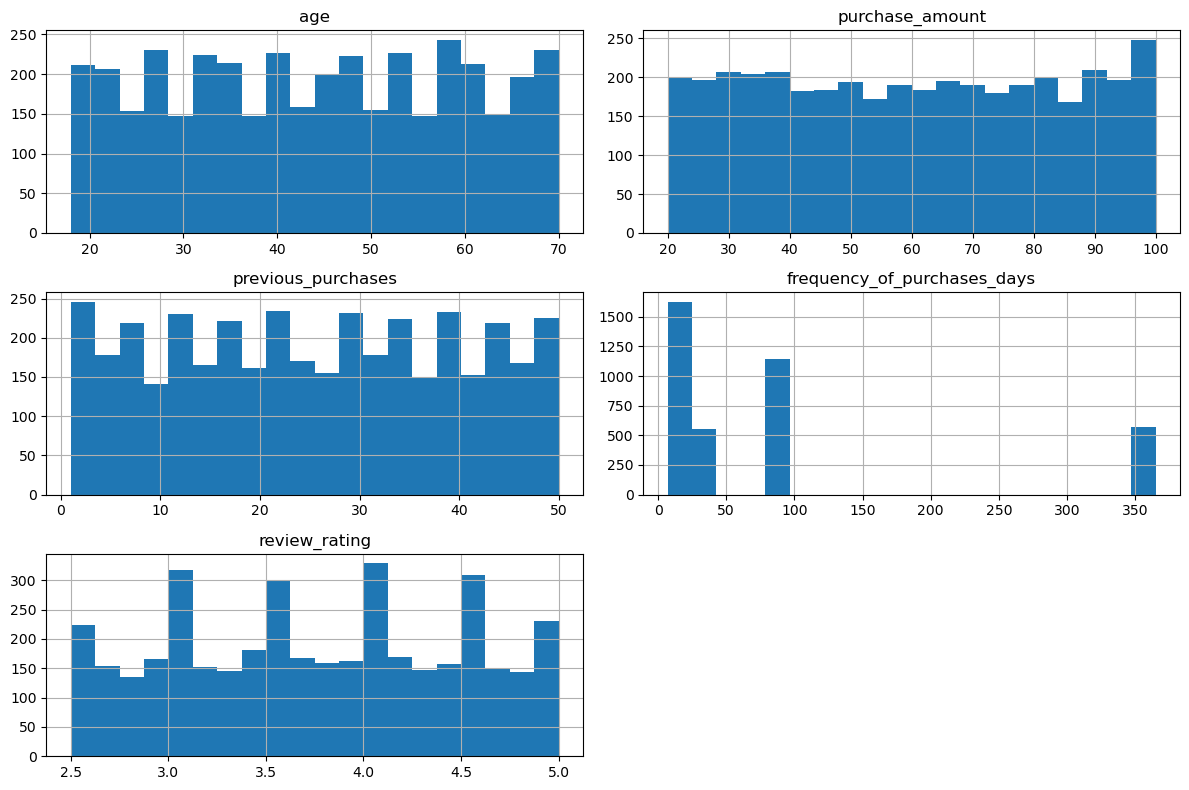

In [14]:
df[features].hist(figsize=(12, 8), bins=20)

plt.tight_layout()
plt.show()

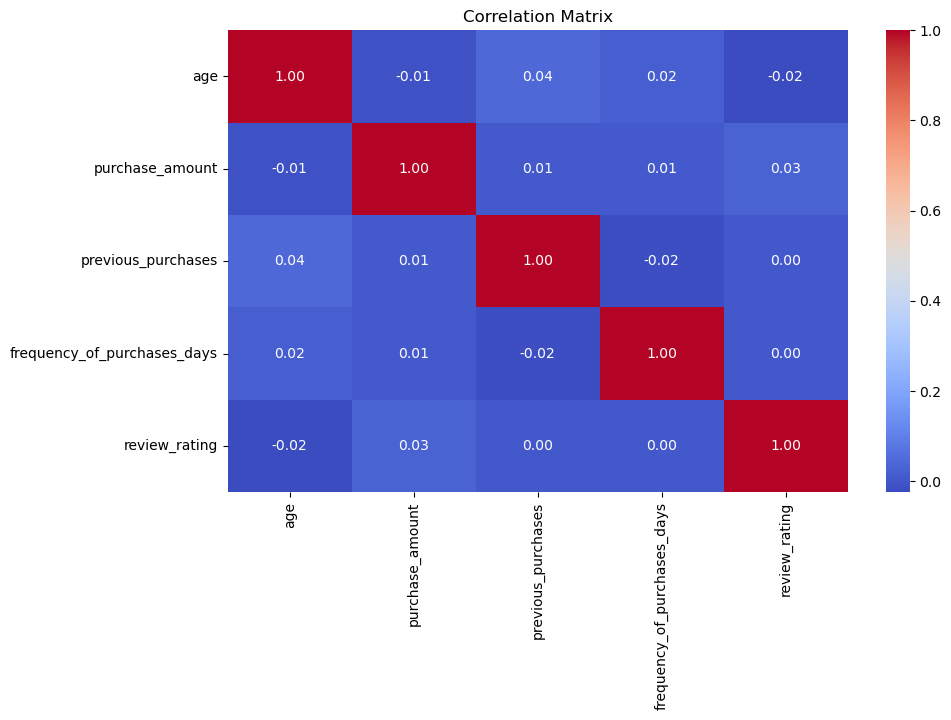

In [15]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df[features].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")
plt.show()

In [16]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(df[features])

scaled_features

array([[ 0.71891344, -0.28562864, -0.78583067, -0.63125208, -0.91107645],
       [-1.64862924,  0.17885219, -1.61655226, -0.63125208, -0.91107645],
       [ 0.39008807,  0.55888195, -0.16278948, -0.69006459, -0.91107645],
       ...,
       [ 0.12702777, -1.13013923, -0.09356268,  0.0072837 , -1.19138555],
       [-0.00450238,  0.72778407, -0.09356268, -0.69006459,  0.0700054 ],
       [ 0.52161822,  0.89668619,  0.52947851,  0.0072837 , -0.91107645]])

In [17]:
scaled_df = pd.DataFrame(
    scaled_features,
    columns=features
)

scaled_df.describe()

,age,purchase_amount,previous_purchases,frequency_of_purchases_days,review_rating
count,3.900000e+03,3.900000e+03,3.900000e+03,3.900000e+03,3.900000e+03
mean,-1.985876e-16,-1.166019e-16,7.287618e-17,-4.645856e-17,2.154402e-16
std,1.000128e+00,1.000128e+00,1.000128e+00,1.000128e+00,1.000128e+00
min,-1.714394e+00,-1.679071e+00,-1.685779e+00,-6.900646e-01,-1.752004e+00
25%,-8.594483e-01,-8.767861e-01,-8.550575e-01,-6.312521e-01,-9.110765e-01
50%,-4.502378e-03,9.950067e-03,-2.433588e-02,-4.968235e-01,7.000540e-02
75%,8.504436e-01,8.966862e-01,8.756125e-01,7.283703e-03,9.109327e-01
max,1.705390e+00,1.698971e+00,1.706334e+00,2.317775e+00,1.751860e+00


In [18]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

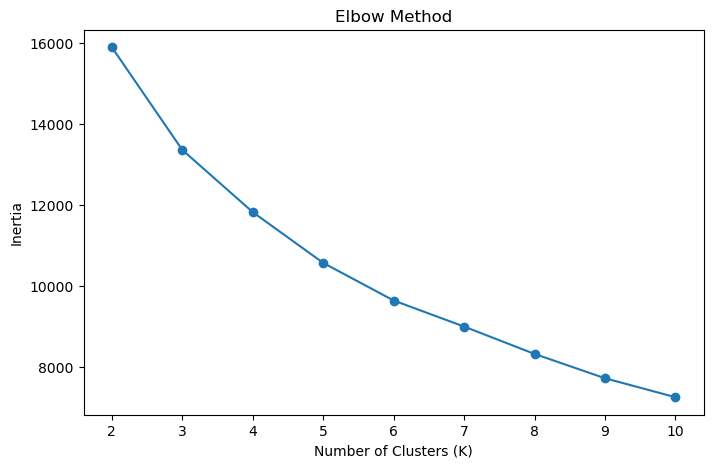

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [20]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_features)
    
    score = silhouette_score(scaled_features, labels)
    silhouette_scores.append(score)

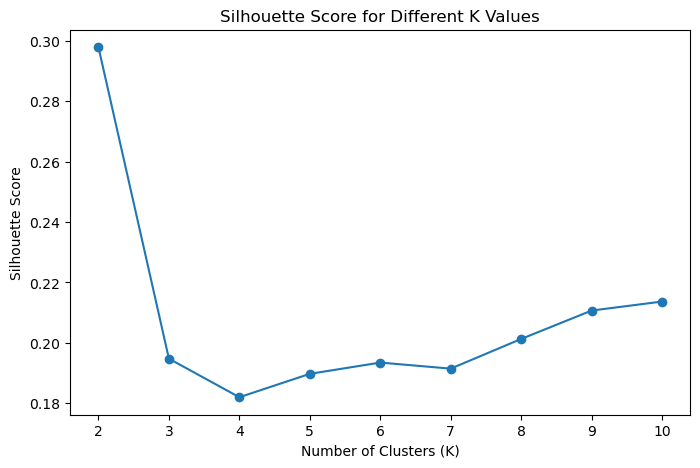

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), silhouette_scores, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")

plt.show()

In [22]:
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.2979
K = 3, Silhouette Score = 0.1948
K = 4, Silhouette Score = 0.1820
K = 5, Silhouette Score = 0.1897
K = 6, Silhouette Score = 0.1935
K = 7, Silhouette Score = 0.1915
K = 8, Silhouette Score = 0.2013
K = 9, Silhouette Score = 0.2107
K = 10, Silhouette Score = 0.2137


In [23]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

df['cluster'] = kmeans.fit_predict(scaled_features)

In [24]:
df['cluster'].value_counts().sort_index()

cluster
0    3328
1     572
Name: count, dtype: int64

In [28]:
cluster_profile = df.groupby('cluster')[features].mean()

cluster_profile

,age,purchase_amount,previous_purchases,frequency_of_purchases_days,review_rating
cluster,,,,,
0,43.965745,59.694111,25.487380,41.71845,3.748798
1,44.666084,60.173077,24.561189,365.00000,3.757343


In [26]:
df['frequency_of_purchases_days'].value_counts().sort_index()

frequency_of_purchases_days
7       539
14     1089
30      553
90     1147
365     572
Name: count, dtype: int64

In [27]:
df.groupby('frequency_of_purchases_days')[[
    'purchase_amount',
    'previous_purchases',
    'age',
    'review_rating'
]].mean()

,purchase_amount,previous_purchases,age,review_rating
frequency_of_purchases_days,,,,
7,58.972171,25.771800,44.649351,3.756401
14,59.877870,25.028466,43.393021,3.733425
30,59.330922,25.278481,44.283906,3.773599
90,60.034002,25.890148,44.034874,3.747864
365,60.173077,24.561189,44.666084,3.757343


In [20]:
features = [
    'age',
    'purchase_amount',
    'previous_purchases',
    'review_rating'
]

In [22]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(df[features])

In [23]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

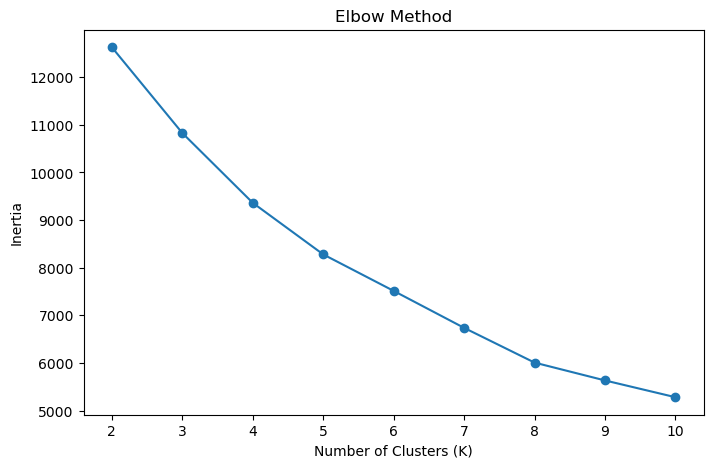

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [25]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_features)
    
    score = silhouette_score(scaled_features, labels)
    silhouette_scores.append(score)

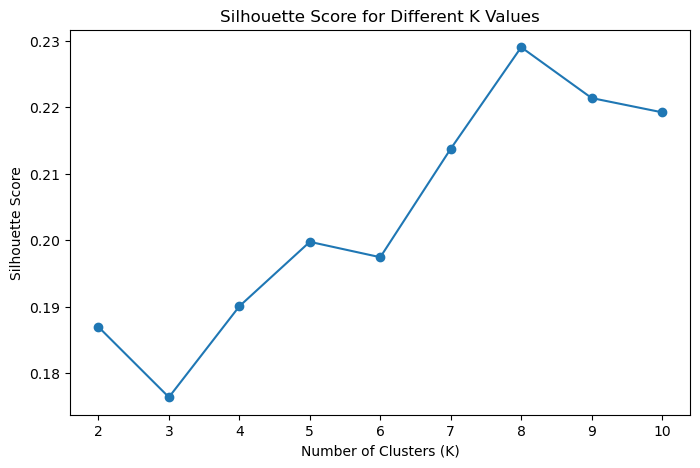

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), silhouette_scores, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")

plt.show()

In [27]:
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.1869
K = 3, Silhouette Score = 0.1764
K = 4, Silhouette Score = 0.1901
K = 5, Silhouette Score = 0.1997
K = 6, Silhouette Score = 0.1974
K = 7, Silhouette Score = 0.2137
K = 8, Silhouette Score = 0.2290
K = 9, Silhouette Score = 0.2214
K = 10, Silhouette Score = 0.2192


In [28]:
for k in [5, 6, 7, 8]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_features)
    
    print(f"\nK = {k}")
    print(pd.Series(labels).value_counts().sort_index())


K = 5
0    812
1    738
2    748
3    742
4    860
Name: count, dtype: int64

K = 6
0    716
1    595
2    650
3    724
4    642
5    573
Name: count, dtype: int64

K = 7
0    594
1    498
2    645
3    602
4    552
5    493
6    516
Name: count, dtype: int64

K = 8
0    444
1    471
2    485
3    497
4    501
5    500
6    493
7    509
Name: count, dtype: int64


In [29]:
for k in [5, 8]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_features)
    
    temp_df = df[features].copy()
    temp_df['cluster'] = labels
    
    print(f"\n===== K = {k} =====")
    print(temp_df.groupby('cluster')[features].mean().round(2))


===== K = 5 =====
           age  purchase_amount  previous_purchases  review_rating
cluster                                                           
0        57.56            78.63               27.05           4.20
1        35.98            42.57               13.09           4.22
2        37.74            76.06               15.49           3.12
3        30.48            62.70               39.70           3.96
4        55.50            40.01               30.47           3.28

===== K = 8 =====
           age  purchase_amount  previous_purchases  review_rating
cluster                                                           
0        57.02            80.70               36.88           3.27
1        32.02            78.41               37.21           4.35
2        56.41            40.66               37.04           4.24
3        33.09            43.09               36.55           3.16
4        54.49            79.33               14.28           4.31
5        56.56          

In [30]:
K = 5

In [31]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df['cluster'] = kmeans.fit_predict(scaled_features)

In [32]:
df['cluster'].value_counts().sort_index()

cluster
0    812
1    738
2    748
3    742
4    860
Name: count, dtype: int64

In [29]:
df.groupby('cluster')['frequency_of_purchases_days'].mean().round(2)

cluster
0     41.72
1    365.00
Name: frequency_of_purchases_days, dtype: float64

In [30]:
pd.crosstab(
    df['cluster'],
    df['frequency_of_purchases_days'],
    normalize='index'
).round(2)

frequency_of_purchases_days,7,14,30,90,365
cluster,,,,,
0,0.16,0.33,0.17,0.34,0.0
1,0.00,0.00,0.00,0.00,1.0


In [31]:
pd.crosstab(
    df['cluster'],
    df['subscription_status'],
    normalize='index'
).round(2)

subscription_status,No,Yes
cluster,,
0,0.73,0.27
1,0.72,0.28


In [32]:
pd.crosstab(
    df['cluster'],
    df['discount_applied'],
    normalize='index'
).round(2)

discount_applied,No,Yes
cluster,,
0,0.57,0.43
1,0.58,0.42


In [33]:
pd.crosstab(
    df['cluster'],
    df['category'],
    normalize='index'
).round(2)

category,Accessories,Clothing,Footwear,Outerwear
cluster,,,,
0,0.32,0.44,0.15,0.08
1,0.32,0.45,0.15,0.08


In [34]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df['cluster'] = kmeans.fit_predict(scaled_features)

In [35]:
df['cluster'].value_counts().sort_index()

cluster
0    804
1    815
2    862
3    847
4    572
Name: count, dtype: int64

In [36]:
cluster_profile = df.groupby('cluster')[features].mean().round(2)

cluster_profile

,age,purchase_amount,previous_purchases,frequency_of_purchases_days,review_rating
cluster,,,,,
0,50.02,37.26,35.93,42.24,3.61
1,46.42,81.52,37.90,43.21,3.94
2,40.68,64.16,15.24,40.66,3.06
3,39.20,55.44,14.05,40.86,4.40
4,44.67,60.17,24.56,365.00,3.76


In [37]:
df.groupby('cluster')['frequency_of_purchases_days'].mean().round(2)

cluster
0     42.24
1     43.21
2     40.66
3     40.86
4    365.00
Name: frequency_of_purchases_days, dtype: float64

In [38]:
pd.crosstab(
    df['cluster'],
    df['subscription_status'],
    normalize='index'
).round(2)

subscription_status,No,Yes
cluster,,
0,0.71,0.29
1,0.72,0.28
2,0.74,0.26
3,0.75,0.25
4,0.72,0.28


In [39]:
pd.crosstab(
    df['cluster'],
    df['discount_applied'],
    normalize='index'
).round(2)

discount_applied,No,Yes
cluster,,
0,0.55,0.45
1,0.57,0.43
2,0.58,0.42
3,0.57,0.43
4,0.58,0.42


In [40]:
pd.crosstab(
    df['cluster'],
    df['category'],
    normalize='index'
).round(2)

category,Accessories,Clothing,Footwear,Outerwear
cluster,,,,
0,0.33,0.42,0.15,0.10
1,0.31,0.45,0.16,0.08
2,0.31,0.47,0.14,0.08
3,0.32,0.43,0.16,0.09
4,0.32,0.45,0.15,0.08


In [41]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

pca_df = pd.DataFrame(
    pca_features,
    columns=['PC1', 'PC2']
)

pca_df['cluster'] = df['cluster']

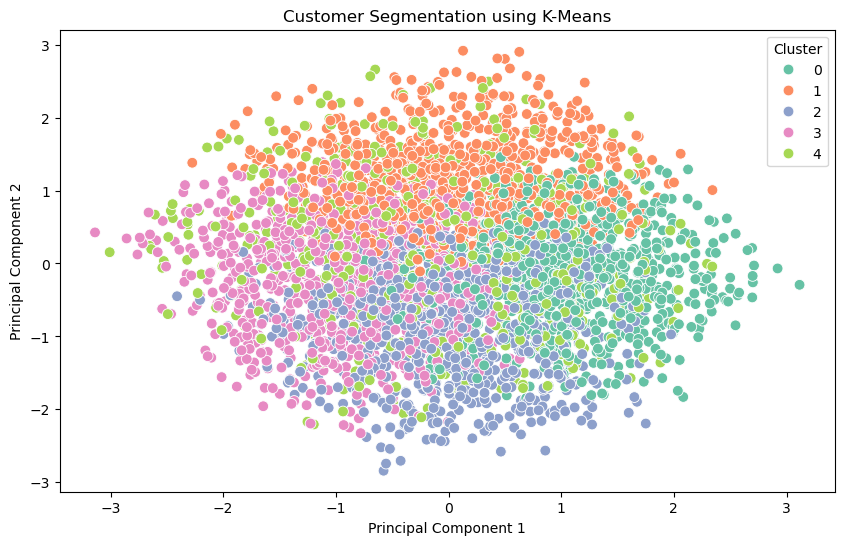

In [42]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='Set2',
    s=60
)

plt.title('Customer Segmentation using K-Means')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')

plt.show()

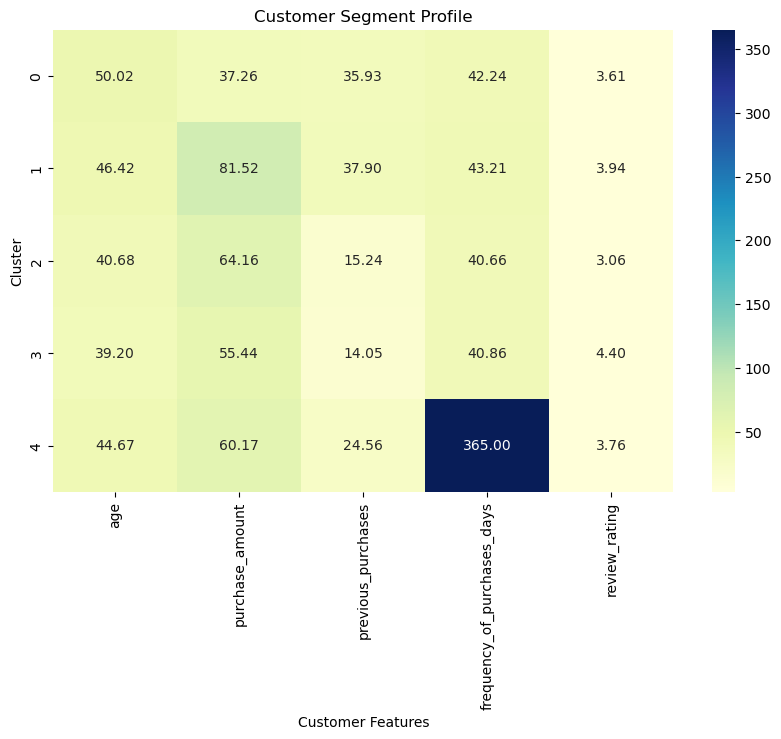

In [43]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Customer Segment Profile')
plt.xlabel('Customer Features')
plt.ylabel('Cluster')

plt.show()

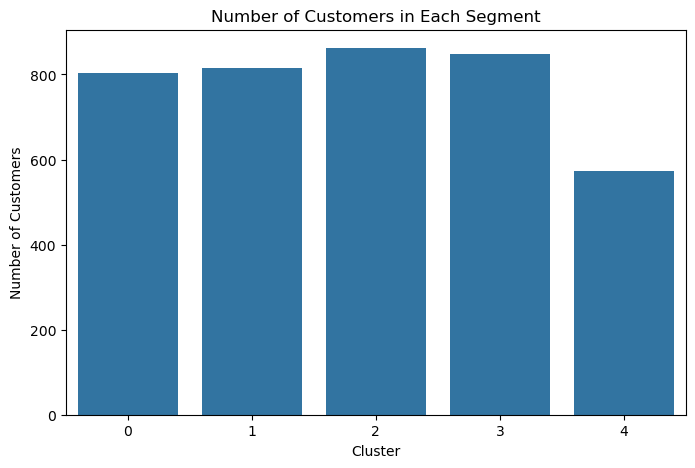

In [44]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='cluster'
)

plt.title('Number of Customers in Each Segment')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')

plt.show()

In [45]:
cluster_profile

,age,purchase_amount,previous_purchases,frequency_of_purchases_days,review_rating
cluster,,,,,
0,50.02,37.26,35.93,42.24,3.61
1,46.42,81.52,37.90,43.21,3.94
2,40.68,64.16,15.24,40.66,3.06
3,39.20,55.44,14.05,40.86,4.40
4,44.67,60.17,24.56,365.00,3.76


In [46]:
segment_names = {
    0: 'Loyal Budget Customers',
    1: 'High-Value Loyal Customers',
    2: 'High-Spending At-Risk Customers',
    3: 'Young Satisfied Customers',
    4: 'Occasional Customers'
}

df['segment'] = df['cluster'].map(segment_names)

df[['customer_id', 'cluster', 'segment']].head()

,customer_id,cluster,segment
0,1,2,High-Spending At-Risk Customers
1,2,2,High-Spending At-Risk Customers
2,3,2,High-Spending At-Risk Customers
3,4,1,High-Value Loyal Customers
4,5,4,Occasional Customers


In [47]:
df['segment'].value_counts()

segment
High-Spending At-Risk Customers    862
Young Satisfied Customers          847
High-Value Loyal Customers         815
Loyal Budget Customers             804
Occasional Customers               572
Name: count, dtype: int64

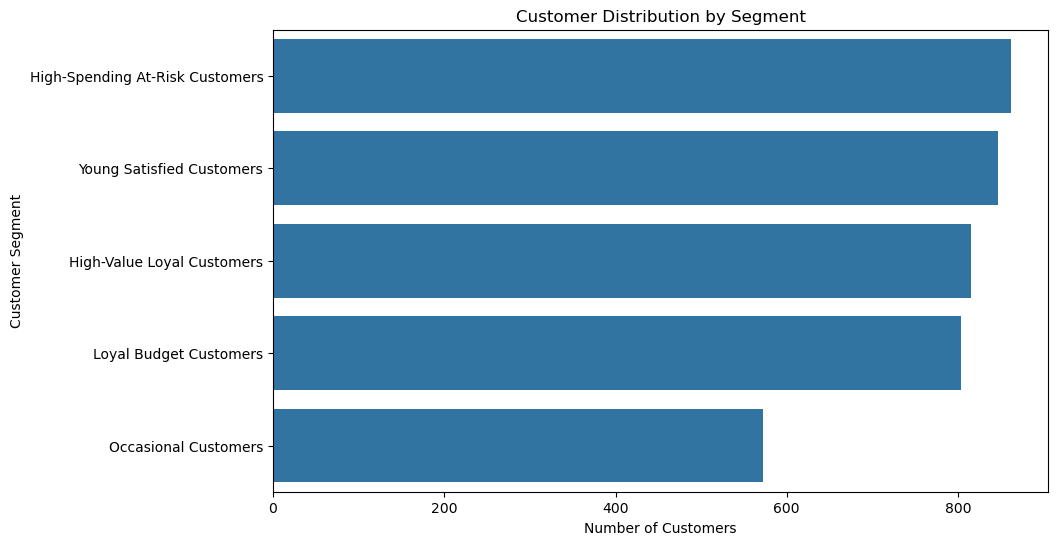

In [48]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y='segment',
    order=df['segment'].value_counts().index
)

plt.title('Customer Distribution by Segment')
plt.xlabel('Number of Customers')
plt.ylabel('Customer Segment')

plt.show()

In [49]:
segment_spending = (
    df.groupby('segment')['purchase_amount']
    .mean()
    .sort_values(ascending=False)
)

segment_spending

segment
High-Value Loyal Customers         81.520245
High-Spending At-Risk Customers    64.161253
Occasional Customers               60.173077
Young Satisfied Customers          55.439197
Loyal Budget Customers             37.262438
Name: purchase_amount, dtype: float64

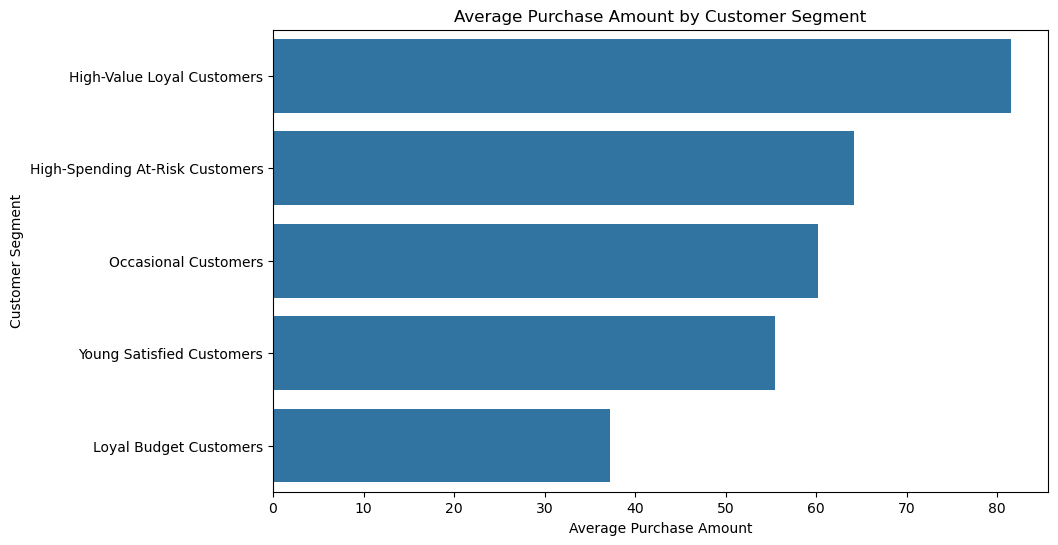

In [50]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=segment_spending.values,
    y=segment_spending.index
)

plt.title('Average Purchase Amount by Customer Segment')
plt.xlabel('Average Purchase Amount')
plt.ylabel('Customer Segment')

plt.show()

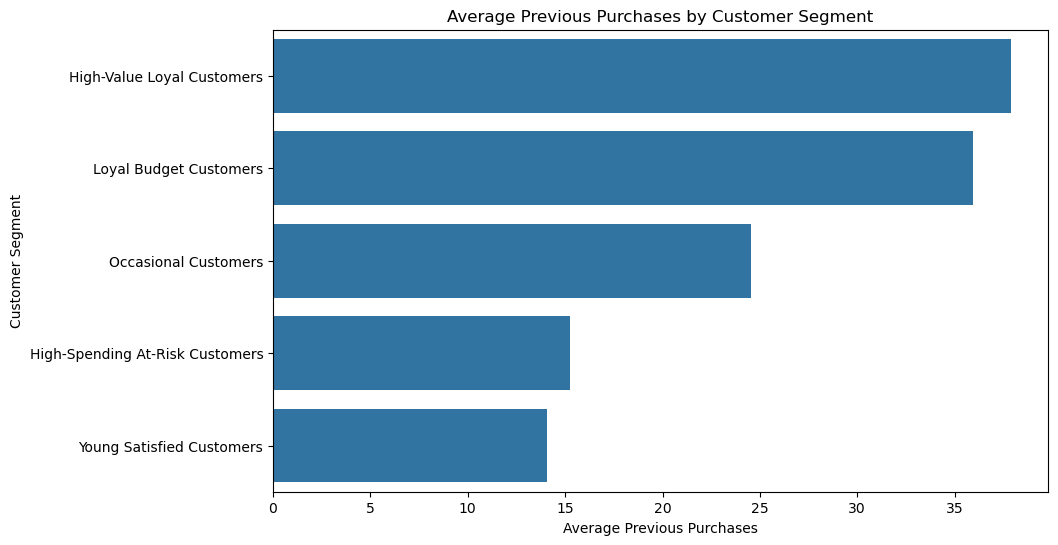

In [51]:
segment_loyalty = (
    df.groupby('segment')['previous_purchases']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=segment_loyalty.values,
    y=segment_loyalty.index
)

plt.title('Average Previous Purchases by Customer Segment')
plt.xlabel('Average Previous Purchases')
plt.ylabel('Customer Segment')

plt.show()

In [52]:
category_pref = pd.crosstab(
    df['segment'],
    df['category'],
    normalize='index'
).round(2)

category_pref

category,Accessories,Clothing,Footwear,Outerwear
segment,,,,
High-Spending At-Risk Customers,0.31,0.47,0.14,0.08
High-Value Loyal Customers,0.31,0.45,0.16,0.08
Loyal Budget Customers,0.33,0.42,0.15,0.10
Occasional Customers,0.32,0.45,0.15,0.08
Young Satisfied Customers,0.32,0.43,0.16,0.09


<Figure size 1000x600 with 0 Axes>

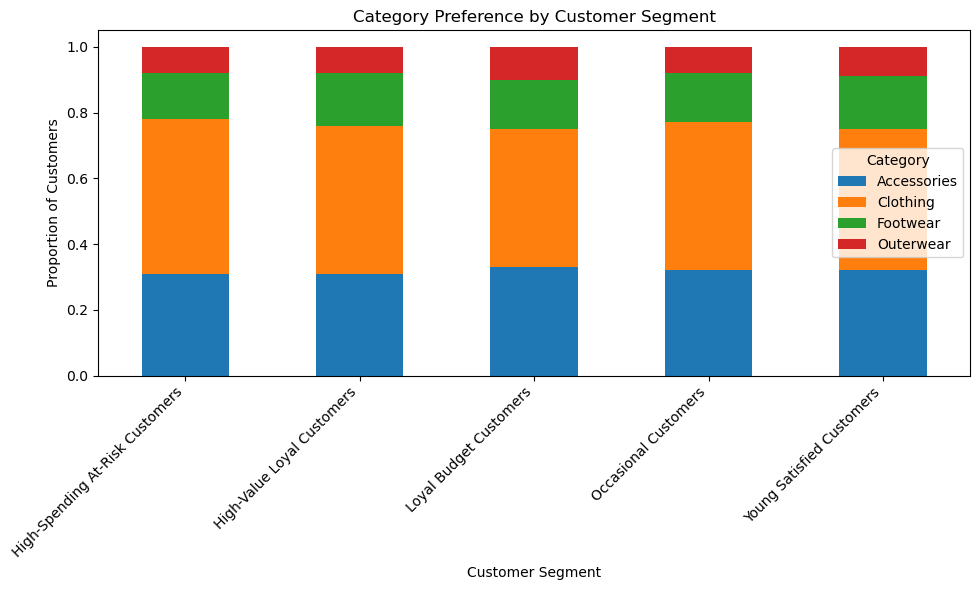

In [53]:
plt.figure(figsize=(10, 6))

category_pref.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title('Category Preference by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Proportion of Customers')
plt.xticks(rotation=45, ha='right')

plt.legend(title='Category')
plt.tight_layout()
plt.show()

In [54]:
subscription_pref = pd.crosstab(
    df['segment'],
    df['subscription_status'],
    normalize='index'
).round(2)

subscription_pref

subscription_status,No,Yes
segment,,
High-Spending At-Risk Customers,0.74,0.26
High-Value Loyal Customers,0.72,0.28
Loyal Budget Customers,0.71,0.29
Occasional Customers,0.72,0.28
Young Satisfied Customers,0.75,0.25


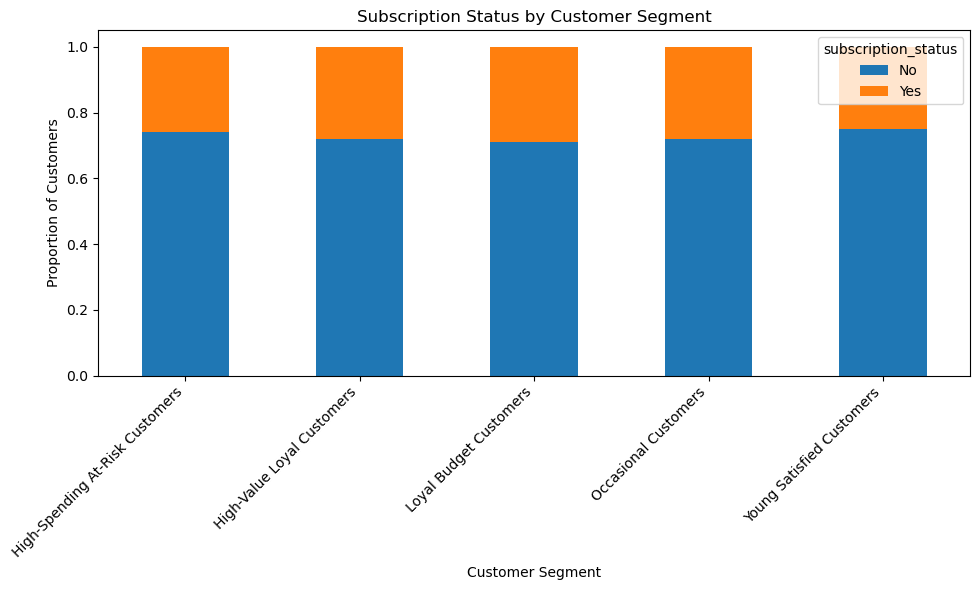

In [55]:
subscription_pref.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title('Subscription Status by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Proportion of Customers')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [56]:
discount_pref = pd.crosstab(
    df['segment'],
    df['discount_applied'],
    normalize='index'
).round(2)

discount_pref

discount_applied,No,Yes
segment,,
High-Spending At-Risk Customers,0.58,0.42
High-Value Loyal Customers,0.57,0.43
Loyal Budget Customers,0.55,0.45
Occasional Customers,0.58,0.42
Young Satisfied Customers,0.57,0.43


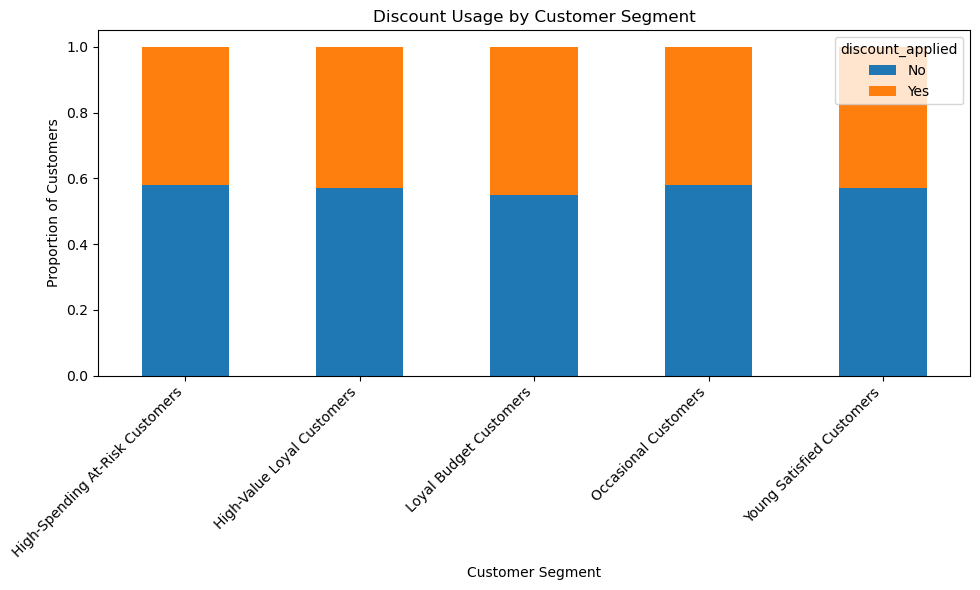

In [57]:
discount_pref.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title('Discount Usage by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Proportion of Customers')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [58]:
payment_pref = pd.crosstab(
    df['segment'],
    df['payment_method'],
    normalize='index'
).round(2)

payment_pref

payment_method,Bank Transfer,Cash,Credit Card,Debit Card,PayPal,Venmo
segment,,,,,,
High-Spending At-Risk Customers,0.18,0.17,0.16,0.16,0.17,0.16
High-Value Loyal Customers,0.14,0.16,0.19,0.18,0.17,0.15
Loyal Budget Customers,0.15,0.18,0.17,0.14,0.19,0.17
Occasional Customers,0.15,0.14,0.17,0.18,0.18,0.18
Young Satisfied Customers,0.16,0.19,0.17,0.16,0.16,0.16


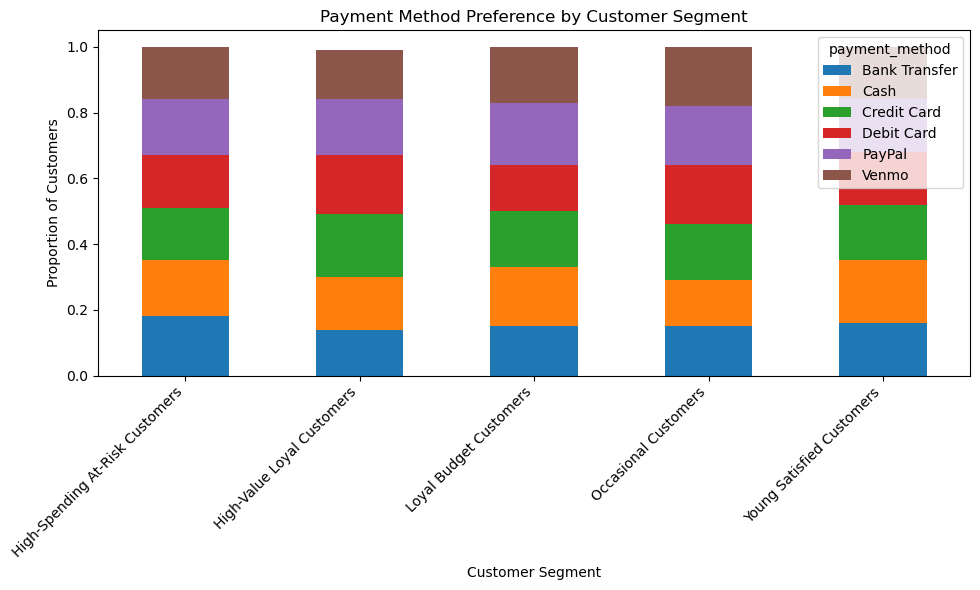

In [59]:
payment_pref.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title('Payment Method Preference by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Proportion of Customers')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [60]:
final_summary = (
    df.groupby('segment')
      .agg(
          customers=('customer_id', 'count'),
          avg_age=('age', 'mean'),
          avg_purchase_amount=('purchase_amount', 'mean'),
          avg_previous_purchases=('previous_purchases', 'mean'),
          avg_purchase_frequency_days=('frequency_of_purchases_days', 'mean'),
          avg_rating=('review_rating', 'mean')
      )
      .round(2)
      .sort_values('avg_purchase_amount', ascending=False)
)

final_summary

,customers,avg_age,avg_purchase_amount,avg_previous_purchases,avg_purchase_frequency_days,avg_rating
segment,,,,,,
High-Value Loyal Customers,815,46.42,81.52,37.90,43.21,3.94
High-Spending At-Risk Customers,862,40.68,64.16,15.24,40.66,3.06
Occasional Customers,572,44.67,60.17,24.56,365.00,3.76
Young Satisfied Customers,847,39.20,55.44,14.05,40.86,4.40
Loyal Budget Customers,804,50.02,37.26,35.93,42.24,3.61


In [62]:
df.to_csv('customer_segments.csv', index=False)

In [5]:
df.to_csv('customer_segments.csv', index=False)

## Targeted Business Recommendations

### 1. High-Value Loyal Customers
- Provide loyalty rewards and exclusive offers.
- Recommend premium products and personalized bundles.
- Encourage repeat purchases through membership benefits.

### 2. High-Spending At-Risk Customers
- Send personalized re-engagement offers.
- Provide limited-time discounts to encourage another purchase.
- Recommend products based on previous purchasing behavior.

### 3. Loyal Budget Customers
- Offer bundle deals and quantity discounts.
- Use cross-selling to increase average purchase value.
- Reward frequent purchases with points or coupons.

### 4. Young Satisfied Customers
- Promote new products and trending categories.
- Use personalized digital campaigns.
- Encourage referrals and social engagement.

### 5. Occasional Customers
- Send personalized discounts to increase purchase frequency.
- Recommend products based on previous purchases.
- Use reminders and seasonal campaigns to bring them back.

## Conclusion

Customer segmentation using K-Means clustering successfully identified distinct customer groups based on demographics and purchasing behavior. These segments can help businesses design targeted marketing strategies, improve customer retention, increase customer value, and provide personalized offers.